In [3]:
!pip install wfdb PyWavelets biosppy EMD-signal scipy numpy matplotlib peakutils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pa

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import pywt
from scipy.signal import spectrogram, savgol_filter, butter, filtfilt
from scipy.stats import pearsonr
from PyEMD import EMD

%matplotlib inline

## Phase 1: Load & Visualize the MIT-BIH Record

In [21]:
import zipfile
import os

zip_path = "/content/mit-bih-arrhythmia-database-1.0.0.zip"
extract_path = "/content/mitdb"

# Extract only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [22]:
def load_record(record_name="100", data_dir="/content/mitdb"):
    # Search for the .hea file
    for root, dirs, files in os.walk(data_dir):
        if f"{record_name}.hea" in files:
            record_path = os.path.join(root, record_name)
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal[:, 0]
            fs = record.fs
            return signal, fs

    raise FileNotFoundError(f"{record_name}.hea not found under {data_dir}")


def plot_time_domain(signal, fs, n_seconds=5, title="Raw ECG"):
    n_samples = int(n_seconds * fs)
    time = np.arange(n_samples) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(time, signal[:n_samples], label=title)
    plt.title(f"{title} (first {n_seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_fft(signal, fs, title="FFT"):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mags = np.abs(np.fft.rfft(signal))
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, mags)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 100)  # ECG-relevant band
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_spectrogram(signal, fs, n_samples=3600, title="ECG Spectrogram"):
    seg = signal[:n_samples]
    f, t, Sxx = spectrogram(seg, fs)
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading="gouraud")
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.colorbar(label="Power (dB)")
    plt.tight_layout()
    plt.show()

In [23]:
RECORD = "100"
TIME_LIMIT_SECONDS = 180  # None = use the full record (~30-45 min); set a number to trim to that many seconds

print(f"Loading MIT-BIH record {RECORD} from PhysioNet...")
signal, fs = load_record(RECORD)
print(f"Loaded {len(signal)} samples at {fs} Hz ({len(signal)/fs:.1f}s).")

if TIME_LIMIT_SECONDS is not None:
    n_keep = int(TIME_LIMIT_SECONDS * fs)
    signal = signal[:n_keep]
    print(f"Trimmed to first {TIME_LIMIT_SECONDS}s -> {len(signal)} samples.")

Loading MIT-BIH record 100 from PhysioNet...
Loaded 650000 samples at 360 Hz (1805.6s).
Trimmed to first 180s -> 64800 samples.


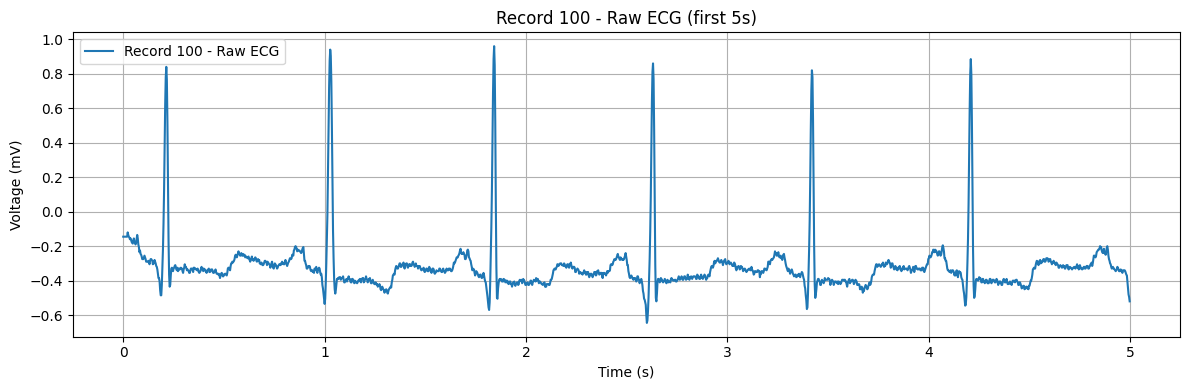

In [24]:
plot_time_domain(signal, fs, n_seconds=5, title=f"Record {RECORD} - Raw ECG")

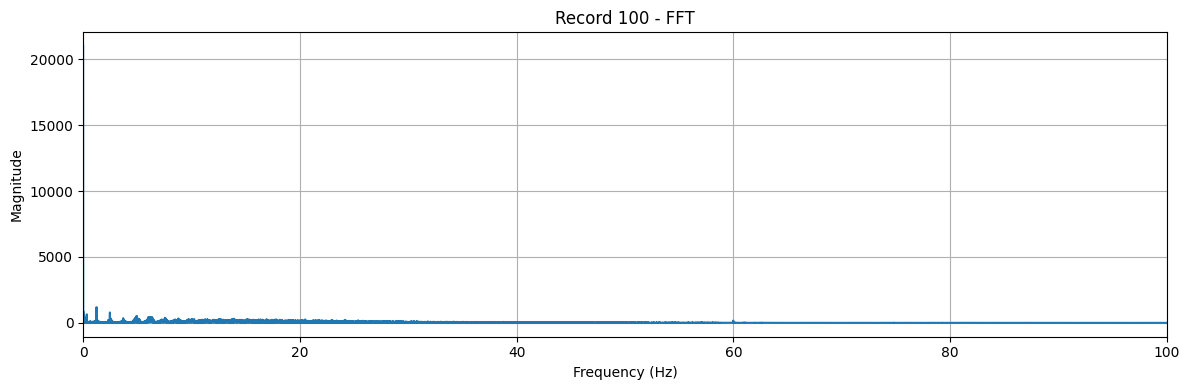

In [25]:
plot_fft(signal, fs, title=f"Record {RECORD} - FFT")

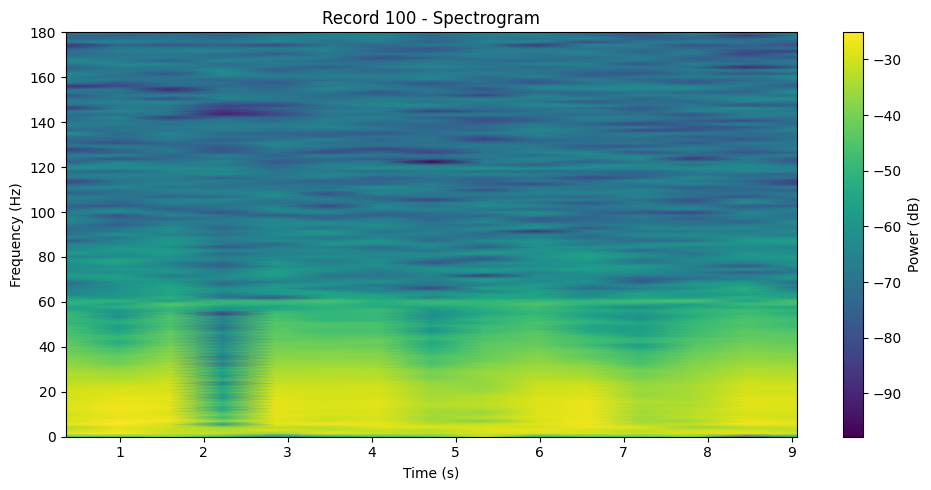

In [26]:
plot_spectrogram(signal, fs, title=f"Record {RECORD} - Spectrogram")

## Phase 2: Denoising Techniques

In [27]:
def denoise_swt(signal, wavelet="rbio3.9", level=5, threshold_scale=0.5):
    """
    Stationary Wavelet Transform denoising (primary / gold-standard method).
    Translation-invariant -> preserves P-QRS-T morphology better than DWT.
    """
    n = len(signal)
    # SWT requires length divisible by 2**level -> pad if necessary
    pad = (2 ** level - n % (2 ** level)) % (2 ** level)
    padded = np.pad(signal, (0, pad), mode="edge")

    coeffs = pywt.swt(padded, wavelet, level=level)  # list of (cA, cD) tuples, coarsest first

    denoised_coeffs = []
    for cA, cD in coeffs:
        sigma = np.median(np.abs(cD)) / 0.6745  # robust noise estimate
        uthresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        cD_denoised = pywt.threshold(cD, uthresh, mode="soft")
        denoised_coeffs.append((cA, cD_denoised))

    reconstructed = pywt.iswt(denoised_coeffs, wavelet)
    return reconstructed[:n]


def denoise_savgol(signal, window_length=17, polyorder=3):
    """
    Savitzky-Golay filter: local polynomial regression smoothing.
    Cheap, preserves R-peak amplitude, good for wearables / real-time use.
    """
    if window_length % 2 == 0:
        window_length += 1  # must be odd
    return savgol_filter(signal, window_length=window_length, polyorder=polyorder)


def denoise_emd(signal, drop_imfs=(0,), energy_ratio_limit=2.0):
    """
    Empirical Mode Decomposition denoising.
    Decomposes the signal into Intrinsic Mode Functions (IMFs) and discards
    the requested indices (e.g. IMF1 = index 0, captures high-freq noise).

    A safeguard checks the energy ratio between original and reconstructed
    signal; if reconstruction blows up (mode mixing), falls back to the
    original signal rather than returning a corrupted one.
    """
    emd = EMD()
    imfs = emd(signal)

    keep_idx = [i for i in range(imfs.shape[0]) if i not in drop_imfs]
    reconstructed = np.sum(imfs[keep_idx], axis=0)

    orig_energy = np.sum(signal ** 2)
    recon_energy = np.sum(reconstructed ** 2)
    ratio = recon_energy / (orig_energy + 1e-12)

    if ratio > energy_ratio_limit or ratio < (1 / energy_ratio_limit):
        print(f"[EMD safeguard] Energy ratio {ratio:.2f} out of bounds -> "
              f"returning original signal unmodified.")
        return signal.copy()

    return reconstructed


def bandpass_baseline_safe(signal, fs, low=0.5, high=40, order=2):
    """
    Optional supporting band-pass filter (0.5-40 Hz) used ahead of R-peak
    detection. Deliberately keeps the high-pass edge at 0.5-1.0 Hz to avoid
    the >90% PRD waveform distortion warned about in the review paper.
    """
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)

In [28]:
swt_out = denoise_swt(signal, wavelet="rbio3.9", level=5, threshold_scale=0.5)
sgs_out = denoise_savgol(signal, window_length=17, polyorder=3)
emd_out = denoise_emd(signal, drop_imfs=(0,))

denoised = {"SWT": swt_out, "Savitzky-Golay": sgs_out, "EMD": emd_out}

### Evaluation metrics: SNR, PRD, Pearson R

In [29]:
def snr_db(clean_ref, noisy):
    """
    SNR improvement metric. Since there is no true clean reference for real
    ECG, this is typically computed against a lightly-filtered 'clean' proxy
    signal rather than the raw signal itself.
    """
    noise = clean_ref - noisy
    signal_power = np.sum(clean_ref ** 2)
    noise_power = np.sum(noise ** 2) + 1e-12
    return 10 * np.log10(signal_power / noise_power)


def prd(original, denoised):
    """Percent Root-Mean-Square Difference."""
    num = np.sqrt(np.sum((original - denoised) ** 2))
    den = np.sqrt(np.sum(original ** 2)) + 1e-12
    return 100 * num / den


def pearson_r(original, denoised):
    r, _ = pearsonr(original, denoised)
    return r


def evaluate_methods(raw, denoised_dict, reference=None):
    """Print a comparison table of PRD and Pearson R for each method."""
    ref = reference if reference is not None else raw
    print(f"{'Method':<15}{'PRD (%)':>12}{'Pearson R':>15}")
    print("-" * 42)
    for name, den in denoised_dict.items():
        p = prd(ref, den)
        r = pearson_r(ref, den)
        print(f"{name:<15}{p:>12.2f}{r:>15.4f}")

In [30]:
print("Evaluation vs raw signal:")
evaluate_methods(signal, denoised)

Evaluation vs raw signal:
Method              PRD (%)      Pearson R
------------------------------------------
SWT                   11.30         0.9772
Savitzky-Golay        12.86         0.9653
EMD                    3.68         0.9970


In [39]:
def plot_denoised_alone(sig, fs, n_seconds=5, title="Denoised"):
    n = int(n_seconds * fs)
    time = np.arange(n) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(time, sig[:n], color="tab:orange")
    plt.title(f"{title} (first {n_seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_denoised_vs_raw(raw, sig, fs, n_seconds=5, method_name="Denoised"):
    n = int(n_seconds * fs)
    time = np.arange(n) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(time, raw[:n], label="Raw", alpha=0.5, color="gray")
    plt.plot(time, sig[:n], label=method_name, color="tab:orange")
    plt.title(f"{method_name} vs Raw (first {n_seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Per-method visualizations

For each denoising method: (1) the denoised signal on its own, then (2) the denoised signal overlaid with the raw signal, and finally (3) all three methods combined with the raw signal in one figure.

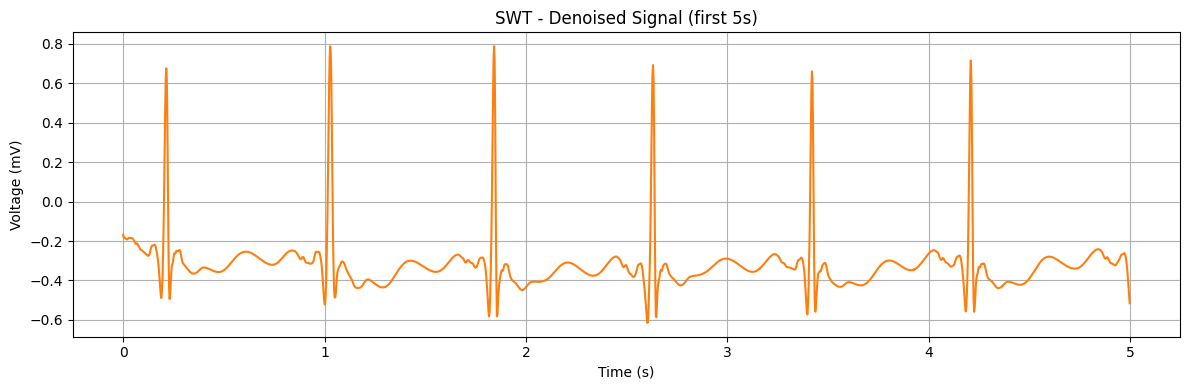

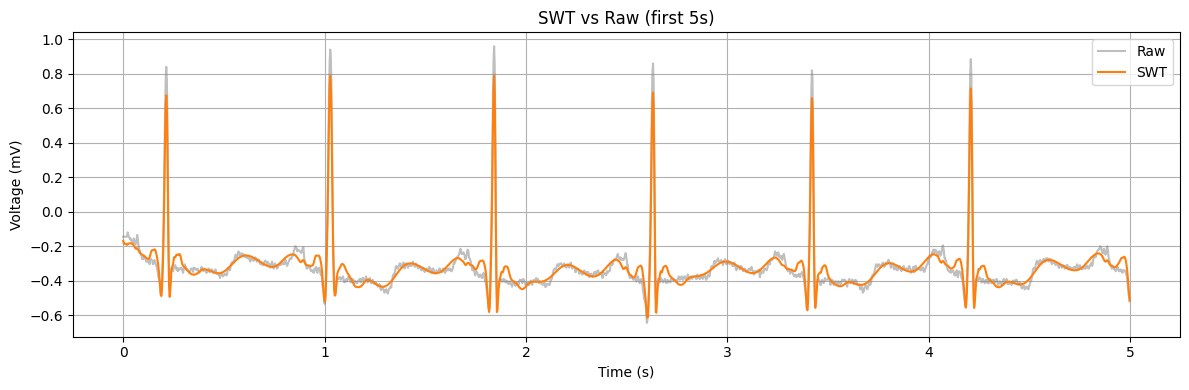

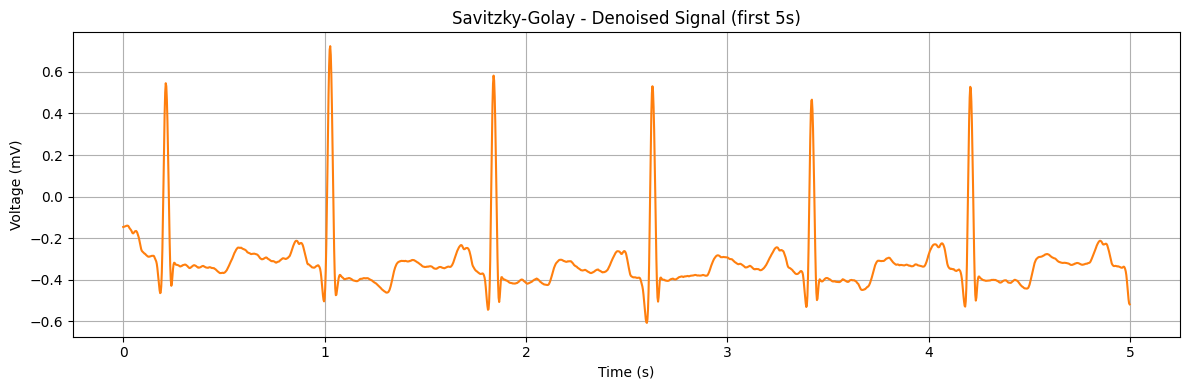

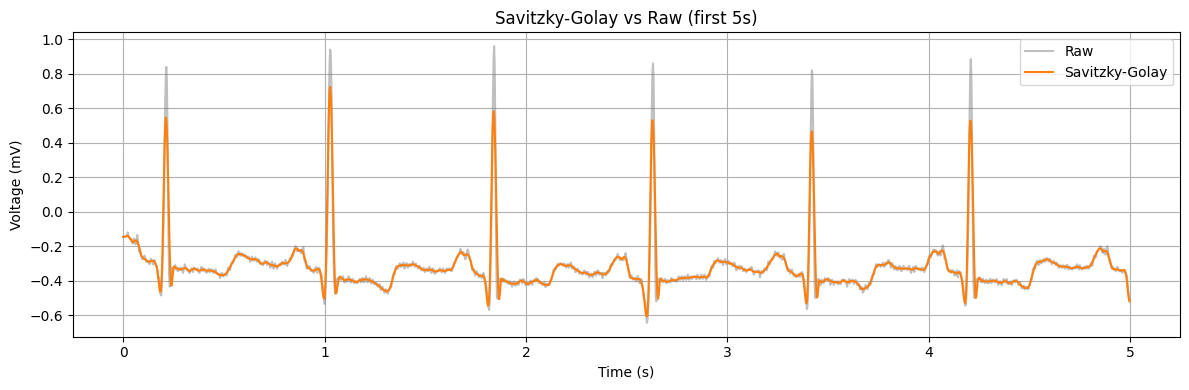

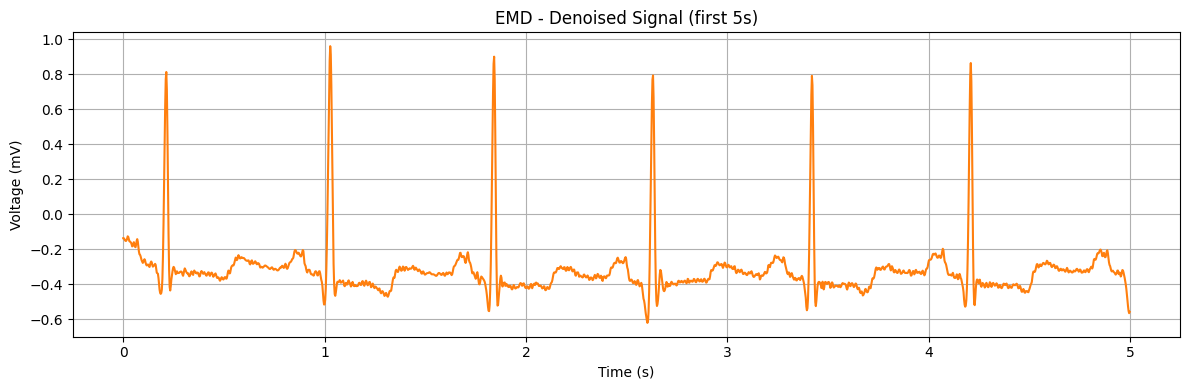

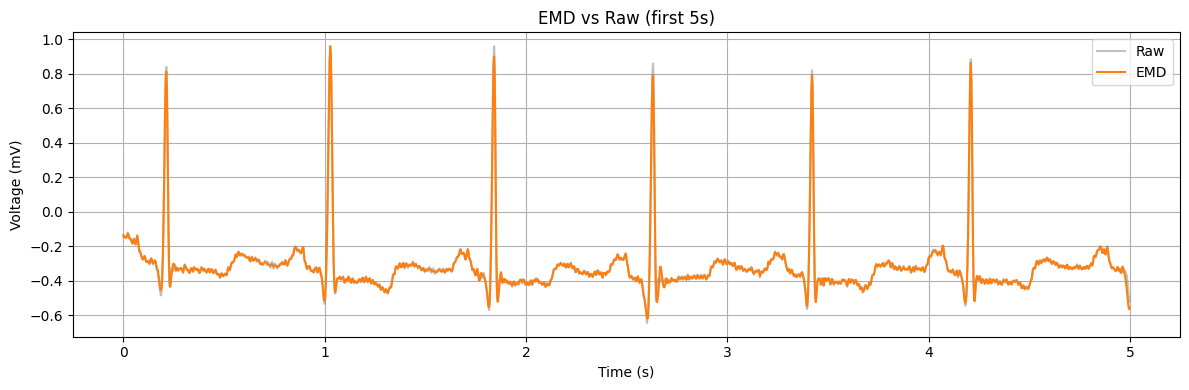

In [40]:
N_SECONDS_COMPARISON = 5

for method_name, sig in denoised.items():
    plot_denoised_alone(sig, fs, n_seconds=N_SECONDS_COMPARISON, title=f"{method_name} - Denoised Signal")
    plot_denoised_vs_raw(signal, sig, fs, n_seconds=N_SECONDS_COMPARISON, method_name=method_name)

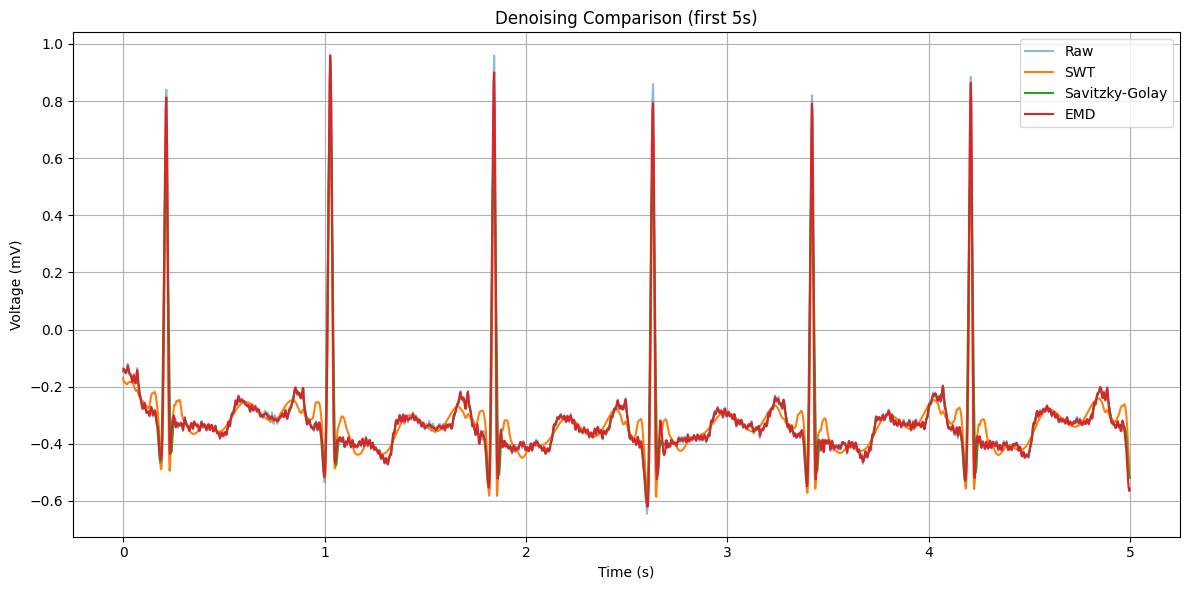

In [31]:
# Visual comparison (first 5 seconds)
n = int(5 * fs)
time = np.arange(n) / fs
plt.figure(figsize=(12, 6))
plt.plot(time, signal[:n], label="Raw", alpha=0.5)
plt.plot(time, swt_out[:n], label="SWT")
plt.plot(time, sgs_out[:n], label="Savitzky-Golay")
plt.plot(time, emd_out[:n], label="EMD")
plt.title("Denoising Comparison (first 5s)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Final: all three methods combined with the raw signal

In [32]:
def snr_db(clean_ref, noisy):
    """
    SNR improvement metric. Since there is no true clean reference for real
    ECG, this is typically computed against a lightly-filtered 'clean' proxy
    signal rather than the raw signal itself.
    """
    noise = clean_ref - noisy
    signal_power = np.sum(clean_ref ** 2)
    noise_power = np.sum(noise ** 2) + 1e-12
    return 10 * np.log10(signal_power / noise_power)


def prd(original, denoised):
    """Percent Root-Mean-Square Difference."""
    num = np.sqrt(np.sum((original - denoised) ** 2))
    den = np.sqrt(np.sum(original ** 2)) + 1e-12
    return 100 * num / den


def pearson_r(original, denoised):
    r, _ = pearsonr(original, denoised)
    return r


def evaluate_methods(raw, denoised_dict, reference=None):
    """Print a comparison table of PRD and Pearson R for each method."""
    ref = reference if reference is not None else raw
    print(f"{'Method':<15}{'PRD (%)':>12}{'Pearson R':>15}")
    print("-" * 42)
    for name, den in denoised_dict.items():
        p = prd(ref, den)
        r = pearson_r(ref, den)
        print(f"{name:<15}{p:>12.2f}{r:>15.4f}")

In [33]:
print("Evaluation vs raw signal:")
evaluate_methods(signal, denoised)

Evaluation vs raw signal:
Method              PRD (%)      Pearson R
------------------------------------------
SWT                   11.30         0.9772
Savitzky-Golay        12.86         0.9653
EMD                    3.68         0.9970


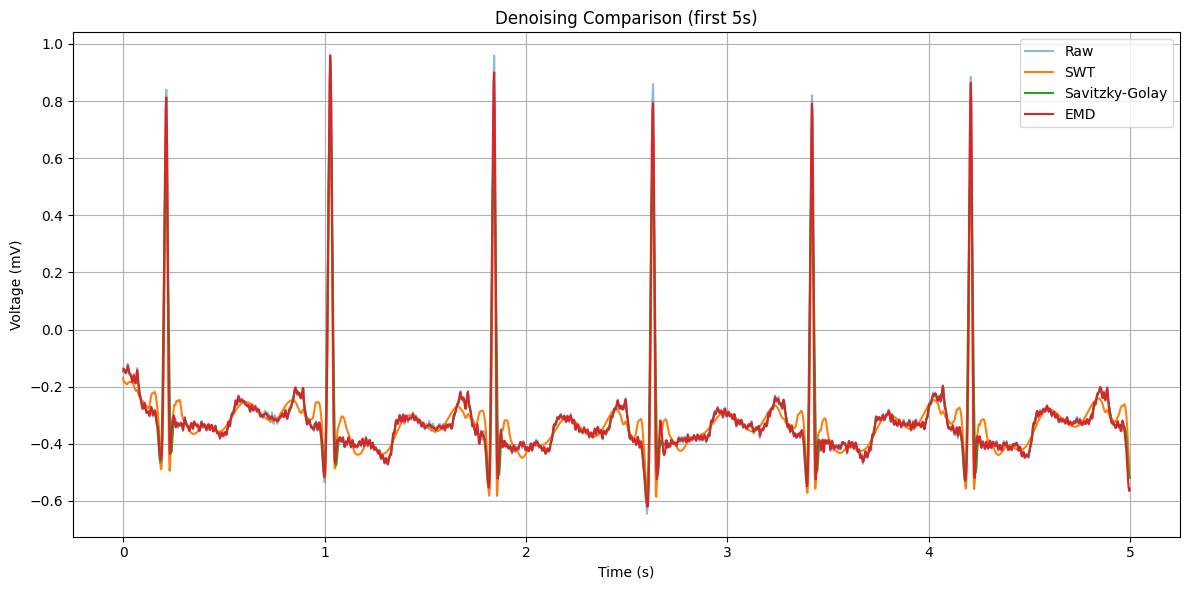

In [34]:
# Visual comparison (first 5 seconds)
n = int(5 * fs)
time = np.arange(n) / fs
plt.figure(figsize=(12, 6))
plt.plot(time, signal[:n], label="Raw", alpha=0.5)
plt.plot(time, swt_out[:n], label="SWT")
plt.plot(time, sgs_out[:n], label="Savitzky-Golay")
plt.plot(time, emd_out[:n], label="EMD")
plt.title("Denoising Comparison (first 5s)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Phase 3: PQRST Feature Extraction


In [35]:
def extract_pqrst_features(signal, fs):
    """
    Uses biosppy's ECG pipeline to detect R-peaks and derive PQRST-related
    timing features.
    """
    from biosppy.signals import ecg as biosppy_ecg

    out = biosppy_ecg.ecg(signal=signal, sampling_rate=fs, show=False)
    r_peaks = out["rpeaks"]

    rr_intervals = np.diff(r_peaks) / fs  # seconds
    heart_rate = 60 / rr_intervals if len(rr_intervals) else np.array([])

    features = {
        "r_peaks_idx": r_peaks,
        "rr_intervals_s": rr_intervals,
        "heart_rate_bpm": heart_rate,
        "mean_hr_bpm": float(np.mean(heart_rate)) if len(heart_rate) else None,
        "hrv_sdnn_ms": float(np.std(rr_intervals) * 1000) if len(rr_intervals) else None,
    }
    return features

In [36]:
features = extract_pqrst_features(swt_out, fs)

n_peaks = len(features["r_peaks_idx"])
print(f"Detected {n_peaks} R-peaks")
if features["mean_hr_bpm"]:
    print(f"Mean HR: {features['mean_hr_bpm']:.1f} bpm")
    print(f"HRV (SDNN): {features['hrv_sdnn_ms']:.1f} ms")

Detected 223 R-peaks
Mean HR: 74.4 bpm
HRV (SDNN): 30.2 ms


## Optional: Data Augmentation (Segment Shuffling)


In [37]:
def segment_shuffle_augment(signal, r_peaks, n_shuffles=1, random_state=None):
    """
    Splits the signal into segments at R-peak boundaries, shuffles the
    segment order, and reconstructs.
    """
    rng = np.random.default_rng(random_state)
    if len(r_peaks) < 2:
        raise ValueError("Need at least 2 R-peaks to segment the signal.")

    boundaries = [0] + list(r_peaks) + [len(signal)]
    segments = [signal[boundaries[i]:boundaries[i + 1]] for i in range(len(boundaries) - 1)]

    augmented_versions = []
    for _ in range(n_shuffles):
        order = rng.permutation(len(segments))
        shuffled = np.concatenate([segments[i] for i in order])
        augmented_versions.append(shuffled)
    return augmented_versions

In [38]:
if len(features["r_peaks_idx"]) >= 2:
    augmented = segment_shuffle_augment(swt_out, features["r_peaks_idx"], n_shuffles=1, random_state=42)
    print(f"Generated {len(augmented)} shuffled-segment augmented signal(s), "
          f"length {len(augmented[0])} samples.")

Generated 1 shuffled-segment augmented signal(s), length 64800 samples.
